Análisis descriptivo de las columnas númericas y obtención de algunas conclusiones

In [3]:
#Importo todas las librerías a usar
import pandas as pd # type: ignore
import numpy as np # type: ignore
from pandas.api.types import is_datetime64_any_dtype as is_datetime # type: ignore
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns # type: ignore

In [7]:
brasil_datos_limpio = pd.read_csv("brasil_datos_limpio", sep = ",", encoding = "latin-1")
print(brasil_datos_limpio.shape)
brasil_datos_limpio.head(5)

(1025721, 13)


,NOME ÃRGÃO SUPERIOR,NOME ÃRGÃO,NOME UNIDADE GESTORA,CATEGORIA ECONÃMICA,ORIGEM RECEITA,ESPÃCIE RECEITA,DETALHAMENTO,VALOR PREVISTO ATUALIZADO,VALOR LANÃADO,VALOR REALIZADO,PERCENTUAL REALIZADO,DATA LANÃAMENTO,ANO EXERCÃCIO
0,Advocacia-Geral da UniÃ£o,Advocacia-Geral da UniÃ£o - Unidades com vÃ­nc...,COORD. GERAL DE ORC. FIN. E ANAL. CONT. - AGU,Receitas Correntes,Outras Receitas Correntes,"Bens, Direitos e Valores Incorporados ao Patr",REC.DIVIDA ATIVA NAO TRIBUTARIA DE OUTRAS REC,0.0,0.0,1297.13,0.0,2013-12-31,2013
1,Advocacia-Geral da UniÃ£o,Advocacia-Geral da UniÃ£o - Unidades com vÃ­nc...,COORD. GERAL DE ORC. FIN. E ANAL. CONT. - AGU,Receitas Correntes,Outras Receitas Correntes,"IndenizaÃ§Ãµes, restituiÃ§Ãµes e ressarcimentos",RECUPERACAO DE DESPESAS DE EXERC. ANTERIORES,0.0,0.0,26666621.42,0.0,2013-12-31,2013
2,Advocacia-Geral da UniÃ£o,Advocacia-Geral da UniÃ£o - Unidades com vÃ­nc...,COORD. GERAL DE ORC. FIN. E ANAL. CONT. - AGU,Receitas Correntes,Outras Receitas Correntes,"Multas administrativas, contratuais e judicia",OUTRAS MULTAS E JUROS DE MORA,0.0,0.0,301251.13,0.0,2013-12-31,2013
3,Advocacia-Geral da UniÃ£o,Advocacia-Geral da UniÃ£o - Unidades com vÃ­nc...,COORD. GERAL DE ORC. FIN. E ANAL. CONT. - AGU,Receitas Correntes,Outras Receitas Correntes,"Bens, Direitos e Valores Incorporados ao Patr",REC.DIV.ATIVA POR INFRAÃÃO ADMINISTRATIVA,0.0,0.0,1855.58,0.0,2013-12-31,2013
4,Advocacia-Geral da UniÃ£o,Advocacia-Geral da UniÃ£o - Unidades com vÃ­nc...,COORD. GERAL DE ORC. FIN. E ANAL. CONT. - AGU,Receitas Correntes,Outras Receitas Correntes,"IndenizaÃ§Ãµes, restituiÃ§Ãµes e ressarcimentos",OUTRAS RESTITUICOES,0.0,0.0,52140.68,0.0,2013-12-31,2013


Distribución de Ingresos por Categoría Económica:
-Analizaremos las categorías de ingresos más significativas y las diferencias entre ingresos previstos e ingresos realizados y calcularemos sus diferencias


In [ ]:
analisis_cat_económicas = brasil_datos_limpio.groupby("CATEGORIA ECONÃMICA")[["VALOR PREVISTO ATUALIZADO", "VALOR REALIZADO"]].sum().reset_index()
analisis_cat_económicas

,CATEGORIA ECONÃMICA,VALOR PREVISTO ATUALIZADO,VALOR REALIZADO
0,Receitas Correntes,1.354953e+13,1.290934e+13
1,Receitas Correntes - intra-orÃ§amentÃ¡rias,2.914850e+11,2.926518e+11
2,Receitas de Capital,1.448575e+13,1.240714e+13
3,Receitas de Capital - intra-orÃ§amentÃ¡rias,1.080841e+10,2.825084e+10
4,Sem informaÃ§Ã£o,0.000000e+00,4.657000e+01


In [16]:
#añado dos columnas nuevas para sacar las diferencias
analisis_cat_económicas['DIFERENCIA NUMÉRICA'] = analisis_cat_económicas['VALOR REALIZADO'] - analisis_cat_económicas['VALOR PREVISTO ATUALIZADO']

# Calcular la diferencia en porcentaje
analisis_cat_económicas['DIFERENCIA PORCENTAJE'] = ((analisis_cat_económicas['VALOR REALIZADO'] - analisis_cat_económicas['VALOR PREVISTO ATUALIZADO']) / analisis_cat_económicas['VALOR PREVISTO ATUALIZADO']) * 100
analisis_cat_económicas.sort_values(by="DIFERENCIA NUMÉRICA", ascending=True)


,CATEGORIA ECONÃMICA,VALOR PREVISTO ATUALIZADO,VALOR REALIZADO,DIFERENCIA NUMÉRICA,DIFERENCIA PORCENTAJE
2,Receitas de Capital,1.448575e+13,1.240714e+13,-2.078617e+12,-14.349387
0,Receitas Correntes,1.354953e+13,1.290934e+13,-6.401838e+11,-4.724769
4,Sem informaÃ§Ã£o,0.000000e+00,4.657000e+01,4.657000e+01,inf
1,Receitas Correntes - intra-orÃ§amentÃ¡rias,2.914850e+11,2.926518e+11,1.166765e+09,0.400283
3,Receitas de Capital - intra-orÃ§amentÃ¡rias,1.080841e+10,2.825084e+10,1.744242e+10,161.378239


<Axes: xlabel='CATEGORIA ECONÃ\x94MICA', ylabel='DIFERENCIA NUMÉRICA'>

C:\Users\ganad\AppData\Roaming\Python\Python312\site-packages\IPython\core\events.py:82: UserWarning: Glyph 148 (\x94) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\ganad\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 148 (\x94) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


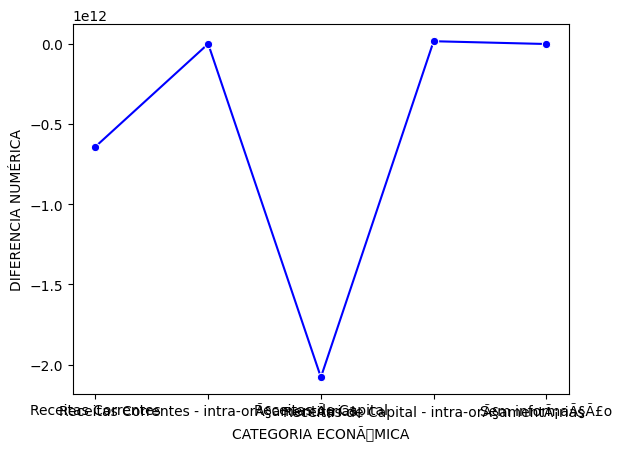

In [25]:
sns.lineplot(x='CATEGORIA ECONÃMICA', y='DIFERENCIA NUMÉRICA', data=analisis_cat_económicas, marker='o', color='blue')

In [26]:
#Añadimos la columna de diferencias al DF inicial también para ver la variación por años 
brasil_datos_limpio['DIFERENCIA PRESUP-REAL'] = brasil_datos_limpio['VALOR REALIZADO'] - brasil_datos_limpio['VALOR PREVISTO ATUALIZADO']
analisis_cat_económicas_anual = brasil_datos_limpio.groupby(["CATEGORIA ECONÃMICA","ANO EXERCÃCIO"])[["VALOR PREVISTO ATUALIZADO", "VALOR REALIZADO","DIFERENCIA PRESUP-REAL"]].sum().reset_index()
analisis_cat_económicas_anual['DIFERENCIA PORCENTAJE'] = ((analisis_cat_económicas_anual['VALOR REALIZADO'] - analisis_cat_económicas_anual['VALOR PREVISTO ATUALIZADO']) / analisis_cat_económicas_anual['VALOR PREVISTO ATUALIZADO']) * 100
analisis_cat_económicas_anual.sort_values(by="DIFERENCIA PORCENTAJE",ascending=True)

,CATEGORIA ECONÃMICA,ANO EXERCÃCIO,VALOR PREVISTO ATUALIZADO,VALOR REALIZADO,DIFERENCIA PRESUP-REAL,DIFERENCIA PORCENTAJE
32,Receitas de Capital - intra-orÃ§amentÃ¡rias,2018,4.436046e+09,5.674575e+08,-3.868588e+09,-87.208035
33,Receitas de Capital - intra-orÃ§amentÃ¡rias,2019,6.372366e+09,2.121983e+09,-4.250383e+09,-66.700234
22,Receitas de Capital,2017,1.927656e+12,1.119288e+12,-8.083683e+11,-41.935301
23,Receitas de Capital,2018,1.951861e+12,1.370787e+12,-5.810740e+11,-29.770260
18,Receitas de Capital,2013,8.564219e+11,6.423447e+11,-2.140772e+11,-24.996695
24,Receitas de Capital,2019,1.597270e+12,1.267873e+12,-3.293971e+11,-20.622500
17,Receitas Correntes - intra-orÃ§amentÃ¡rias,2021,3.138139e+10,2.662545e+10,-4.755941e+09,-15.155290
26,Receitas de Capital,2021,2.516802e+12,2.141542e+12,-3.752598e+11,-14.910188
7,Receitas Correntes,2020,1.700501e+12,1.453998e+12,-2.465030e+11,-14.495903
16,Receitas Correntes - intra-orÃ§amentÃ¡rias,2020,3.552244e+10,3.066600e+10,-4.856434e+09,-13.671454


In [28]:
brasil_datos_limpio['DIFERENCIA PRESUP-REAL'] = brasil_datos_limpio['VALOR REALIZADO'] - brasil_datos_limpio['VALOR PREVISTO ATUALIZADO']
analisis_cat_económicas_anual = brasil_datos_limpio.groupby(["ANO EXERCÃCIO"])[["VALOR PREVISTO ATUALIZADO", "VALOR REALIZADO","DIFERENCIA PRESUP-REAL"]].sum().reset_index()
analisis_cat_económicas_anual['DIFERENCIA PORCENTAJE'] = ((analisis_cat_económicas_anual['VALOR REALIZADO'] - analisis_cat_económicas_anual['VALOR PREVISTO ATUALIZADO']) / analisis_cat_económicas_anual['VALOR PREVISTO ATUALIZADO']) * 100
analisis_cat_económicas_anual.sort_values(by="DIFERENCIA PORCENTAJE",ascending=True)

,ANO EXERCÃCIO,VALOR PREVISTO ATUALIZADO,VALOR REALIZADO,DIFERENCIA PRESUP-REAL,DIFERENCIA PORCENTAJE
4,2017,3.414380e+12,2.558047e+12,-8.563322e+11,-25.080170
5,2018,3.505648e+12,2.942388e+12,-5.632605e+11,-16.067227
0,2013,2.174651e+12,1.893614e+12,-2.810372e+11,-12.923326
6,2019,3.261379e+12,2.991565e+12,-2.698140e+11,-8.273003
2,2015,2.878828e+12,2.665685e+12,-2.131422e+11,-7.403784
8,2021,4.180716e+12,3.876372e+12,-3.043444e+11,-7.279720
1,2014,2.392129e+12,2.238551e+12,-1.535781e+11,-6.420144
3,2016,2.952696e+12,2.839712e+12,-1.129847e+11,-3.826491
7,2020,3.577147e+12,3.631449e+12,5.430191e+10,1.518023


In [34]:
brasil_datos_limpio.columns

Index(['NOME ÃRGÃO SUPERIOR', 'NOME ÃRGÃO', 'NOME UNIDADE GESTORA',
       'CATEGORIA ECONÃMICA', 'ORIGEM RECEITA', 'ESPÃCIE RECEITA',
       'DETALHAMENTO', 'VALOR PREVISTO ATUALIZADO', 'VALOR LANÃADO',
       'VALOR REALIZADO', 'PERCENTUAL REALIZADO', 'DATA LANÃAMENTO',
       'ANO EXERCÃCIO', 'DIFERENCIA PRESUP-REAL'],
      dtype='object')

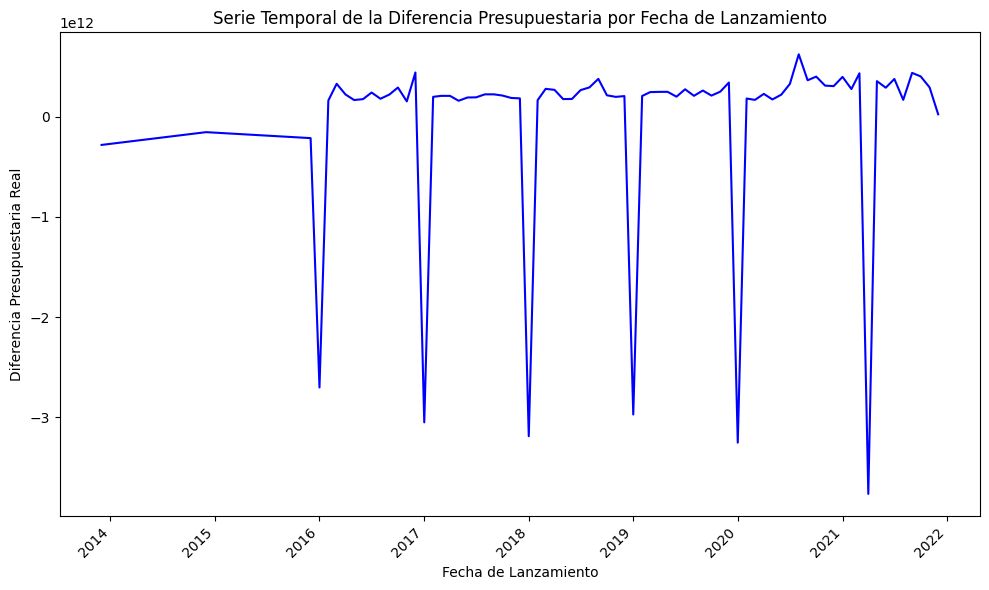

In [42]:
#Voy a crear una serie temporal para ver las diferencias

brasil_datos_limpio['DATA LANÃAMENTO'] = pd.to_datetime(brasil_datos_limpio['DATA LANÃAMENTO'], errors='coerce')



df_agrupado = brasil_datos_limpio.groupby(brasil_datos_limpio['DATA LANÃAMENTO'].dt.to_period('M'))['DIFERENCIA PRESUP-REAL'].sum().reset_index()

# Convertimos la columna de periodos a timestamp para que sea legible
df_agrupado['DATA LANÃAMENTO'] = df_agrupado['DATA LANÃAMENTO'].dt.to_timestamp()

# Crear el gráfico de la serie temporal
plt.figure(figsize=(10, 6))
sns.lineplot(x='DATA LANÃAMENTO', y='DIFERENCIA PRESUP-REAL', data=df_agrupado, color='blue')

# Añadir título y etiquetas
plt.title('Serie Temporal de la Diferencia Presupuestaria por Fecha de Lanzamiento')
plt.xlabel('Fecha de Lanzamiento')
plt.ylabel('Diferencia Presupuestaria Real')

# Mejorar el formato de las fechas en el eje X
plt.xticks(rotation=45, ha='right')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

Analizando la serie temporal vewmos que las mayores diferencias se producen en los meses de diciembre de 2016 en adelante. Esto se debe a que son las fechas donde se realizan los presupuestos. Para evitar esto, podrían implementar un control presupuestario mensual.

Por otro lado también observamos que "Receitas de Capital" hacia abajo  y "Receitas de Capital - intra-orÃ§amentÃ¡rias" hacia arriba son las categorías que más diferencias tienen en lo presupuestado y lo real y son las categorías en las que habría que poner una mayor vigilancia. 

El año con mayor diferencia fue 2017 (un -25% entre lo presupuestado y lo real) y, paradójicamente el año con menos diferencia fue 2020 (el año del covid). Si analizamos las diferencias entre lo presupuestado y lo real, vemos que, todos los años salvo 2020, las diferencias son negativas (se espera más de lo que se obtiene). Brasil debería tener mucho cuidado con esto ya que, seguramente, harán los gastos en función de los ingresos previstos y parece que siempre preveen más ingresos de los esperados. Para mejorar esto podrían ser menos ambiciosos en cuanto a lo esperado y ajustarse más en función de los años anteriores. 

Analizando especificamente uno a uno por año y categoría económica, vemos que existe un grave problema en los presupuestos de "Receitas de Capital - intra-orÃ§amentÃ¡rias" en los años 2018 y 2019 (un -80 y -60% de desviación). Se debería hacer un especial incapié en esta seccion y en analizar que paso durante esos años para evitar que vuelva a suceder en el futuro.




